# Prevalence Experiment Analysis

RIFT failure mode prevalence across five rubric datasets, comparing against paper Table 2.

- **Human-crafted**: AdvancedIF (ADV), ResearchRubrics (RES)
- **Synthetic**: WildChecklists (WC), OpenRubrics (OR), AutoRubrics (AR)

All `results/prevalence_*.jsonl` files are loaded automatically and indexed by judge.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from sklearn.metrics import cohen_kappa_score

sns.set_theme(style="whitegrid", palette="muted")

RESULTS_DIR = Path("../results")

FAILURE_MODES = [
    "subjective", "non_atomic", "ungrounded", "misaligned_or_rigid",
    "missing_criteria", "hackable", "low_signal", "redundant_criteria",
]

SOURCES = ["advancedif", "researchrubrics", "wildchecklists", "openrubrics", "autorubrics"]
SOURCE_SHORT = {"advancedif": "ADV", "researchrubrics": "RES",
                "wildchecklists": "WC", "openrubrics": "OR", "autorubrics": "AR"}
SOURCE_GROUP = {"advancedif": "human", "researchrubrics": "human",
                "wildchecklists": "synthetic", "openrubrics": "synthetic", "autorubrics": "synthetic"}

JUDGE_SHORT = {
    "gpt-5.2-2025-12-11":     "GPT-5.2",
    "gpt-5.4-2026-03-05":     "GPT-5.4",
    "gemini-3.1-pro-preview": "Gemini-3.1-Pro",
    "gemini-3.1-flash-lite":  "Gemini-3.1-Flash",
}

# Paper Table 2 reference values
TABLE2 = {
    "human":     {"subjective": 52.6, "non_atomic": 26.3, "ungrounded": 42.1,
                  "misaligned_or_rigid": 63.2, "missing_criteria": 47.4,
                  "hackable": 0.0, "low_signal": 21.1, "redundant_criteria": 26.3},
    "synthetic": {"subjective": 86.7, "non_atomic": 60.0, "ungrounded": 46.7,
                  "misaligned_or_rigid": 20.0, "missing_criteria": 36.7,
                  "hackable": 13.3, "low_signal": 40.0, "redundant_criteria": 23.3},
}


## Load results

In [2]:
def load_file(path: Path) -> pd.DataFrame:
    records = [json.loads(l) for l in path.read_text().splitlines() if l.strip()]
    df = pd.DataFrame(records)
    for fm in FAILURE_MODES:
        df[fm] = df["labels"].apply(lambda ls: fm in ls)
    df["group"] = df["source"].map(SOURCE_GROUP)
    return df

# Load most recent file per judge
results: dict[str, pd.DataFrame] = {}
for path in sorted(RESULTS_DIR.glob("prevalence_*.jsonl"), reverse=True):
    df = load_file(path)
    judge = df["judge_model"].iloc[0]
    if judge not in results:
        results[judge] = df
        print(f"  Loaded {path.name}  judge={JUDGE_SHORT.get(judge, judge)}  n={len(df)}")

judges = sorted(results)
print(f"\nJudges: {[JUDGE_SHORT.get(j,j) for j in judges]}")
for judge in judges:
    df = results[judge]
    print(f"  {JUDGE_SHORT.get(judge,judge)}: " +
          ", ".join(f"{s}={len(df[df['source']==s])}" for s in SOURCES))

  Loaded prevalence_20260518T050424Z.jsonl  judge=Gemini-3.1-Flash  n=250
  Loaded prevalence_20260518T041230Z.jsonl  judge=GPT-5.2  n=250

Judges: ['Gemini-3.1-Flash', 'GPT-5.2']
  Gemini-3.1-Flash: advancedif=50, researchrubrics=50, wildchecklists=50, openrubrics=50, autorubrics=50
  GPT-5.2: advancedif=50, researchrubrics=50, wildchecklists=50, openrubrics=50, autorubrics=50


## Per-source prevalence — per judge

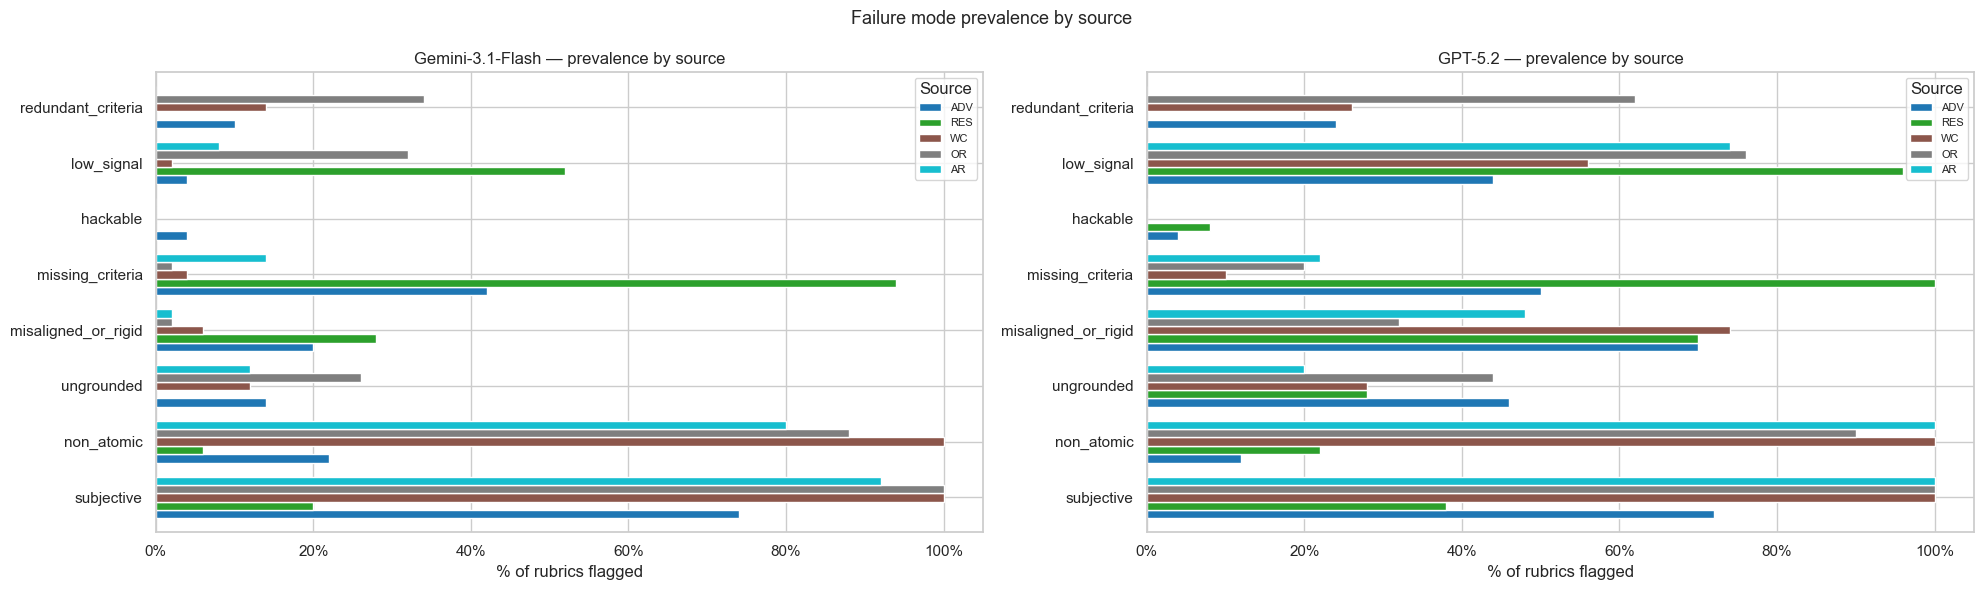

In [3]:
n_judges = len(judges)
fig, axes = plt.subplots(1, n_judges, figsize=(10 * n_judges, 6), squeeze=False)

for ax, judge in zip(axes[0], judges):
    df = results[judge]
    pivot = pd.DataFrame({
        SOURCE_SHORT[s]: df[df["source"] == s][FAILURE_MODES].mean() * 100
        for s in SOURCES if s in df["source"].values
    })
    pivot.plot(kind="barh", ax=ax, width=0.75, colormap="tab10")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"{JUDGE_SHORT.get(judge, judge)} — prevalence by source")
    ax.set_xlabel("% of rubrics flagged")
    ax.legend(title="Source", fontsize=8)

plt.suptitle("Failure mode prevalence by source", fontsize=13)
plt.tight_layout()
plt.show()

## Human vs synthetic — comparison to paper Table 2

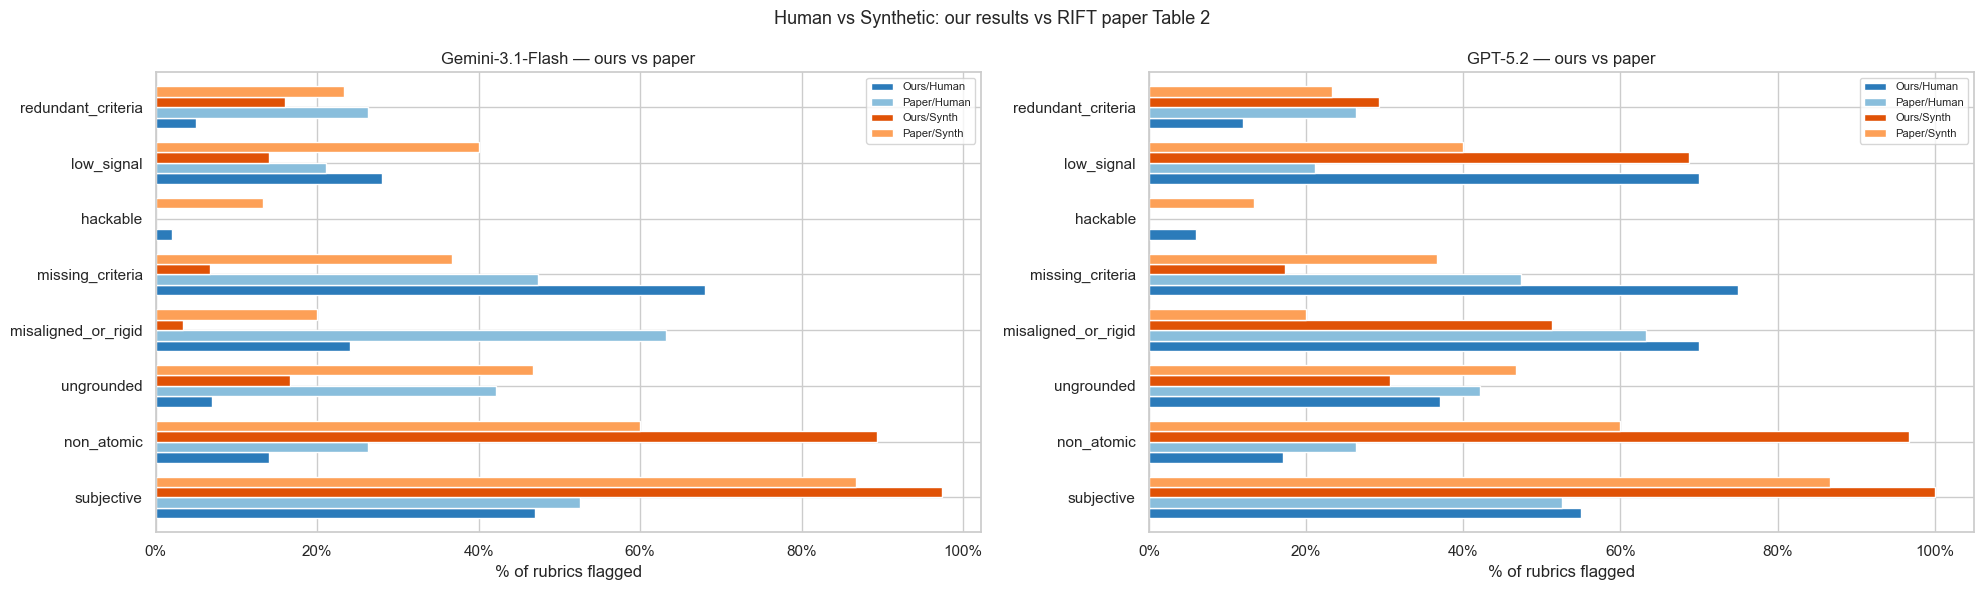

In [4]:
fig, axes = plt.subplots(1, n_judges, figsize=(10 * n_judges, 6), squeeze=False)

for ax, judge in zip(axes[0], judges):
    df = results[judge]
    compare = pd.DataFrame({
        "Ours/Human":    df[df["group"]=="human"][FAILURE_MODES].mean() * 100,
        "Paper/Human":   pd.Series(TABLE2["human"]),
        "Ours/Synth":    df[df["group"]=="synthetic"][FAILURE_MODES].mean() * 100,
        "Paper/Synth":   pd.Series(TABLE2["synthetic"]),
    })
    colors = [sns.color_palette("Blues")[4], sns.color_palette("Blues")[2],
              sns.color_palette("Oranges")[4], sns.color_palette("Oranges")[2]]
    compare.plot(kind="barh", ax=ax, width=0.75, color=colors)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"{JUDGE_SHORT.get(judge, judge)} — ours vs paper")
    ax.set_xlabel("% of rubrics flagged")
    ax.legend(fontsize=8)

plt.suptitle("Human vs Synthetic: our results vs RIFT paper Table 2", fontsize=13)
plt.tight_layout()
plt.show()

## Heatmap: prevalence across sources per judge

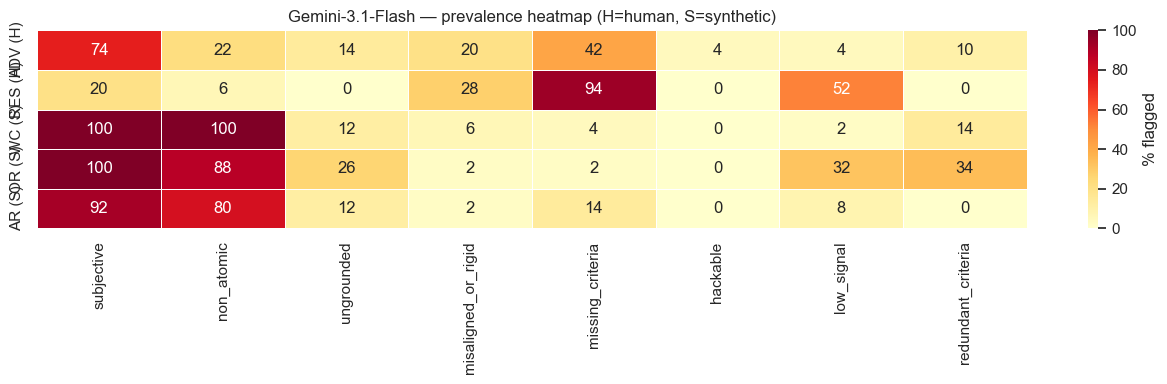

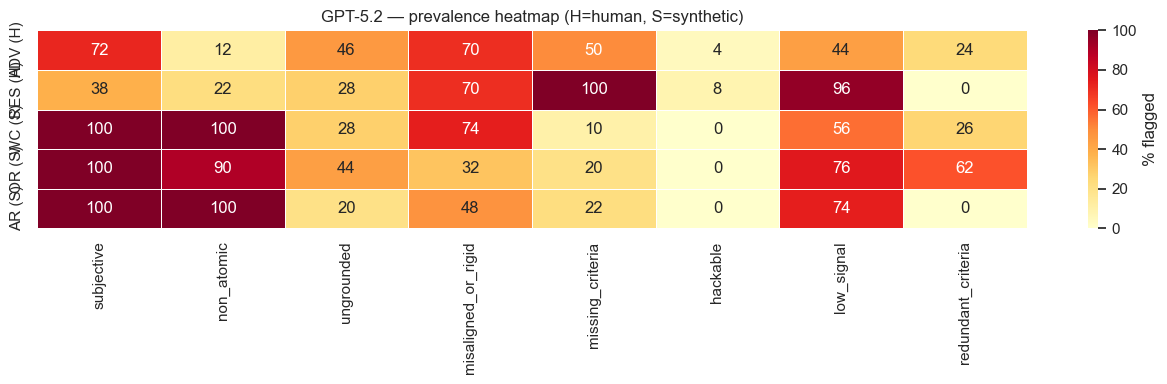

In [5]:
for judge in judges:
    df = results[judge]
    heatmap_df = pd.DataFrame({
        SOURCE_SHORT[s]: df[df["source"] == s][FAILURE_MODES].mean() * 100
        for s in SOURCES if s in df["source"].values
    }).T
    # Add human/synthetic group label
    heatmap_df.index = [
        f"{short} ({'H' if SOURCE_GROUP[s]=='human' else 'S'})"
        for s, short in SOURCE_SHORT.items() if s in df["source"].values
    ]

    fig, ax = plt.subplots(figsize=(13, 4))
    sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="YlOrRd",
                vmin=0, vmax=100, linewidths=0.5, ax=ax,
                cbar_kws={"label": "% flagged"})
    ax.set_title(f"{JUDGE_SHORT.get(judge, judge)} — prevalence heatmap (H=human, S=synthetic)")
    plt.tight_layout()
    plt.show()

## Cross-judge comparison

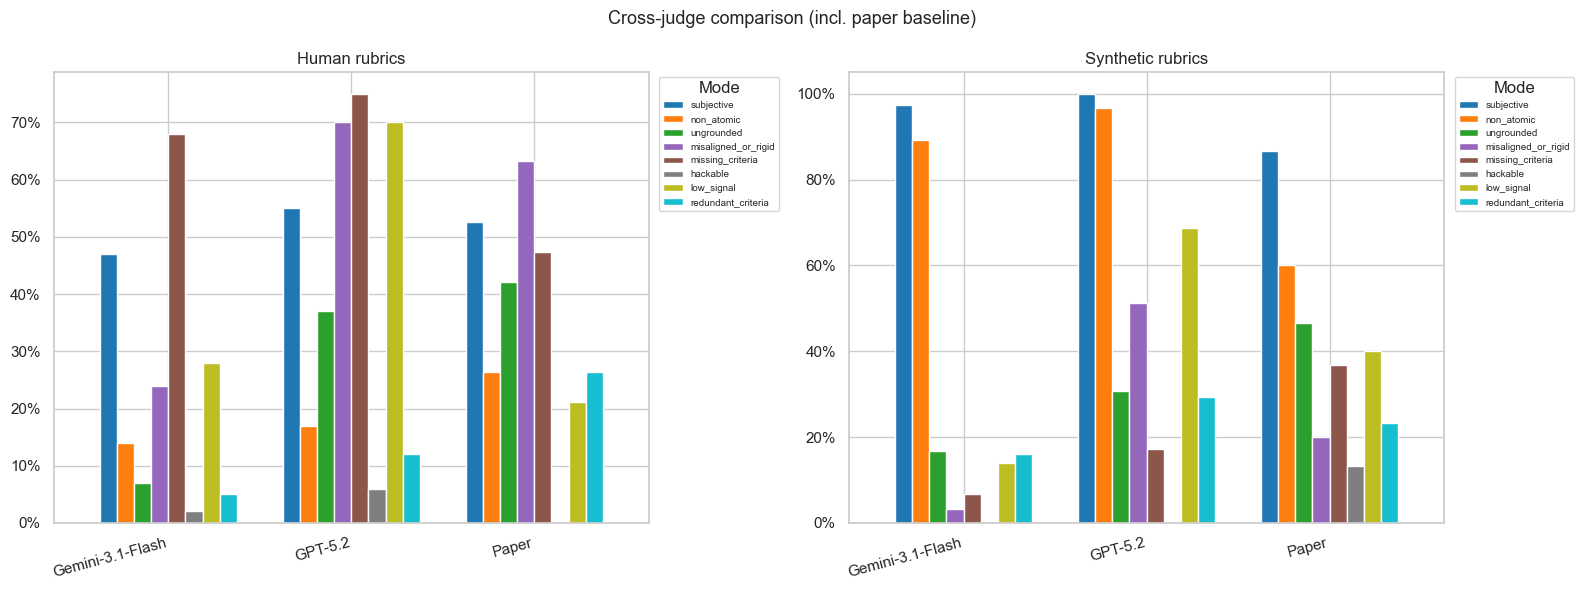

In [6]:
if len(judges) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, group in zip(axes, ["human", "synthetic"]):
        cross = pd.DataFrame({
            JUDGE_SHORT.get(j, j): results[j][results[j]["group"] == group][FAILURE_MODES].mean() * 100
            for j in judges
        })
        cross[f"Paper"] = pd.Series(TABLE2[group])
        cross.T.plot(kind="bar", ax=ax, width=0.75, colormap="tab10")
        ax.yaxis.set_major_formatter(mtick.PercentFormatter())
        ax.set_title(f"{group.capitalize()} rubrics")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha="right")
        ax.legend(title="Mode", fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.suptitle("Cross-judge comparison (incl. paper baseline)", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 2 judges for cross-judge comparison.")

## Cross-judge agreement (Cohen's kappa) per source

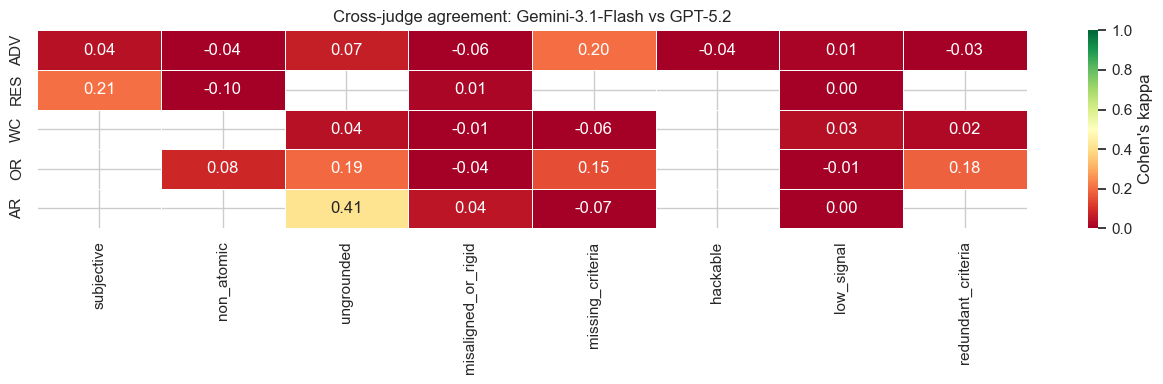

     subjective  non_atomic  ungrounded  misaligned_or_rigid  missing_criteria  hackable  low_signal  redundant_criteria
ADV        0.04       -0.04        0.07                -0.06              0.20     -0.04        0.01               -0.03
RES        0.21       -0.10         NaN                 0.01               NaN       NaN        0.00                 NaN
WC          NaN         NaN        0.04                -0.01             -0.06       NaN        0.03                0.02
OR          NaN        0.08        0.19                -0.04              0.15       NaN       -0.01                0.18
AR          NaN         NaN        0.41                 0.04             -0.07       NaN        0.00                 NaN


In [7]:
if len(judges) >= 2:
    j1, j2 = judges[0], judges[1]
    df1, df2 = results[j1], results[j2]

    kappa_rows = {}
    for source in SOURCES:
        s1 = df1[df1["source"] == source]
        s2 = df2[df2["source"] == source]
        # align by index position (same loader seed → same order)
        n = min(len(s1), len(s2))
        kappa_rows[SOURCE_SHORT[source]] = {}
        for fm in FAILURE_MODES:
            a = s1[fm].iloc[:n].astype(int)
            b = s2[fm].iloc[:n].astype(int)
            if a.nunique() > 1 and b.nunique() > 1:
                kappa_rows[SOURCE_SHORT[source]][fm] = cohen_kappa_score(a, b)
            else:
                kappa_rows[SOURCE_SHORT[source]][fm] = float("nan")

    kappa_df = pd.DataFrame(kappa_rows).T

    fig, ax = plt.subplots(figsize=(13, 4))
    sns.heatmap(kappa_df, annot=True, fmt=".2f", cmap="RdYlGn",
                vmin=0, vmax=1, linewidths=0.5, ax=ax,
                cbar_kws={"label": "Cohen's kappa"})
    ax.set_title(f"Cross-judge agreement: {JUDGE_SHORT.get(j1,j1)} vs {JUDGE_SHORT.get(j2,j2)}")
    plt.tight_layout()
    plt.show()

    print(kappa_df.to_string(float_format="{:.2f}".format))
else:
    print("Need at least 2 judges for agreement analysis.")

## Failure mode co-occurrence (per judge)

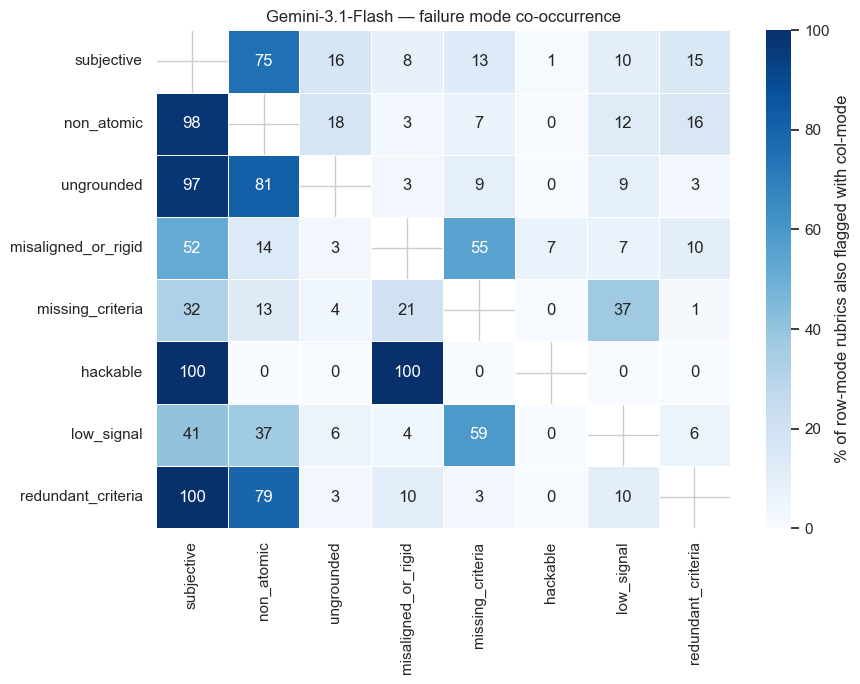

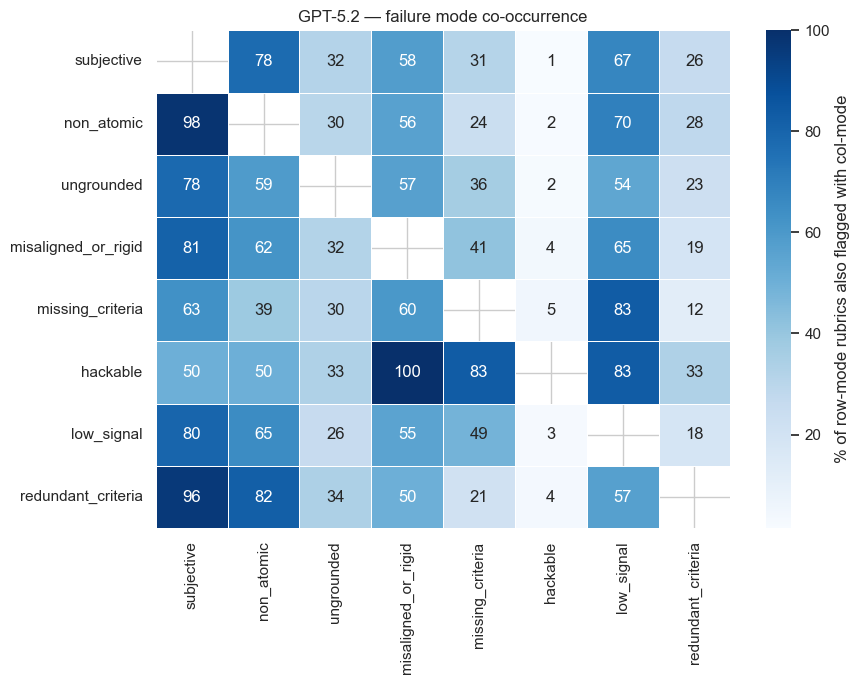

In [8]:
for judge in judges:
    df = results[judge]
    cooc = df[FAILURE_MODES].astype(int).T.dot(df[FAILURE_MODES].astype(int))
    cooc_pct = cooc.div(cooc.values.diagonal(), axis=0) * 100
    mask = pd.DataFrame([[i == j for j in FAILURE_MODES] for i in FAILURE_MODES],
                        index=FAILURE_MODES, columns=FAILURE_MODES)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cooc_pct, annot=True, fmt=".0f", cmap="Blues",
                linewidths=0.5, ax=ax, mask=mask,
                cbar_kws={"label": "% of row-mode rubrics also flagged with col-mode"})
    ax.set_title(f"{JUDGE_SHORT.get(judge, judge)} — failure mode co-occurrence")
    plt.tight_layout()
    plt.show()

## Data quality checks

Errors, vote consistency, and n_votes distribution across loaded files.


In [9]:
for judge, df in results.items():
    label = JUDGE_SHORT.get(judge, judge)
    n_votes = int(df["n_votes"].iloc[0]) if "n_votes" in df.columns else 1
    errors = df["error"].notna().sum() if "error" in df.columns else 0
    print(f"\n{label}  (n={len(df)}, n_votes={n_votes})")
    print(f"  Errors: {errors}/{len(df)}")
    if errors:
        print(df[df["error"].notna()][["source","error"]].to_string(index=False))

    # vote consistency: unanimous vs split
    if "votes" in df.columns and n_votes > 1:
        threshold = (n_votes // 2) + 1
        unanimous, split, zero = 0, 0, 0
        for _, row in df.iterrows():
            votes = row["votes"] or []
            if not votes:
                continue
            dedup_counts = {}
            for v in votes:
                seen = set()
                for lbl in v:
                    if lbl not in seen:
                        dedup_counts[lbl] = dedup_counts.get(lbl, 0) + 1
                        seen.add(lbl)
            final = [l for l, c in dedup_counts.items() if c >= threshold]
            if not final:
                zero += 1
            elif all(dedup_counts.get(l, 0) == n_votes for l in final):
                unanimous += 1
            else:
                split += 1
        print(f"  Vote consistency — unanimous: {unanimous}, split majority: {split}, no labels: {zero}")



Gemini-3.1-Flash  (n=250, n_votes=5)
  Errors: 0/250
  Vote consistency — unanimous: 143, split majority: 104, no labels: 3

GPT-5.2  (n=250, n_votes=5)
  Errors: 0/250
  Vote consistency — unanimous: 97, split majority: 153, no labels: 0
